In [2]:
from adiabatic_computation.hamiltonian import H_B
import numpy as np
n = 2

np.diagonal(H_B(n))

array([2.4705603, 1.7696385, 1.3830801, 2.3723598, 1.6714379, 1.2848794,
       2.3188646, 1.6179427, 1.2313843], dtype=float32)

T_f = 50.0
T_f = 100.0
T_f = 150.0
T_f = 200.0
T_f = 250.0
T_f = 300.0
T_f = 350.0
T_f = 400.0
T_f = 450.0
T_f = 500.0
T_f = 550.0
T_f = 600.0
T_f = 650.0
T_f = 700.0
T_f = 750.0
T_f = 800.0
T_f = 850.0
T_f = 900.0
T_f = 950.0
T_f = 1000.0
T_f = 1050.0
T_f = 1100.0
T_f = 1150.0
T_f = 1200.0
T_f = 1250.0
T_f = 1300.0
T_f = 1350.0
T_f = 1400.0
T_f = 1450.0
T_f = 1500.0


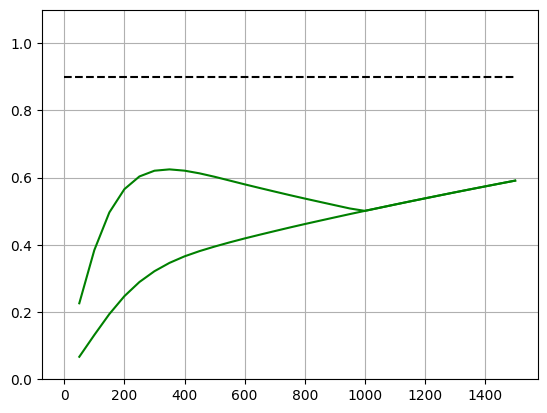

In [4]:
"""This script is a direct translation of the MATLAB implementatoin of the
qutrit-annealing scheme for the Zermelo problem.
"""

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

# Inputs to the LZ anneal.
# Qutrits
n = 4

# River model
v = 1
S0 = .9*v
D = 1
def Smod(x):
    return S0*np.exp(-2*(x - D/np.pi)**2)

# Assign length of transversal step
dy = 0.2*D/n

# Weights
alpha = 1     # Weight of exploration term
Pen = 5       # Penalty

# Time inputs
TFmin = 50
TFmax = 1500
TFincrement = 50

#
# End of inputs
#

# Setting up the terms in the Hamiltonian and the corresponding propagators.
# Dimensionality
N = 3**n

#
# Necessary functions
#

# Constructs big Kronecker product of vectors
def SingleQutritVec(V, k):
    return np.kron(np.kron(np.ones(3**(k-1)), V), np.ones(3**(n-k)))
      
# Constructs big Kronecker product of matrices
def SingleQutritMat(M, k):
    return np.kron(np.kron(np.eye(3**(k-1)), M), np.eye(3**(n-k)))

# Calculates time-weights from current model 
def TimeWeights(k):
    # Cost
    dx = D/n
    x = (k-1/2)*dx

    # The average current at this step
    S = Smod(x)    
    # Time costs for upwards, straight and downwards
    tUp = (dx**2+dy**2)/(np.sqrt((dx**2+dy**2)*v**2-dx**2*S**2)-dy*S)
    tStraight = dx/np.sqrt(v**2-S**2)
    tDown = (dx**2+dy**2)/(np.sqrt((dx**2+dy**2)*v**2-dx**2*S**2)+dy*S)
    # Arrange them into a column vector
    return np.array([tUp, tStraight, tDown])

#
# Sets up the cost Hamiltonian (diagonal)
#
Hcost = np.zeros(N)
for k in range(1,n+1):
  times =TimeWeights(k)
  Hcost += SingleQutritVec(times, k)

#
# Sets up the exploration Hamiltonian
#
sigmaX = 1/np.sqrt(2)*np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]])
Hexplore = np.zeros((N, N))
for k in range(1,n+1):
    Hexplore += SingleQutritMat(sigmaX, k)

#
# Sets up the penalty Hamiltonian (diagonal)
#
Hpenalty = np.zeros(N)
sigmaZdiag = np.array([1, 0, -1])
for k in range(1,n+1):
  Hpenalty += SingleQutritVec(sigmaZdiag, k)

# Square penalty (elementwise)
Hpenalty = Hpenalty**2

Hf = Hcost+ Pen * Hpenalty
# 
# Run the anneal for various anneal times
#

TFvector = np.arange(TFmin, TFmax+1, TFincrement, dtype=float)
FidVector = 0*TFvector  # Allocate
FidVector2 = 0*TFvector  # Allocate


# Initiate state
PlusState = .5*np.array([1, np.sqrt(2), 1])
Psi0 = 1
for k in range(1,n+1):
  Psi0 = np.kron(PlusState, Psi0)

#
# Function which solves the TDSE for the anneal
#
def SolveTDSE_Yves(Psi, TF, Nsteps): 
    """This function implements a specific case of the time-dependent
    Schrödinger equation by means of a split operator technique."""
    
    # Time step
    dt = TF/Nsteps

    # Initiate factors in the propagator sandwich.
    B = la.expm(+1j*alpha*(1-dt/(2*TF))*Hexplore*dt)
    Bincrement = la.expm(-1j*alpha*dt**2/TF*Hexplore)


    # Propagate
    t = 0                      # Initiate time
    for TimeInd in range(1,Nsteps+1):
        # Update state (split operator)
        Ahalf = np.exp(-1j*(t+dt/2)/TF*(Hcost+Pen*Hpenalty)*dt/2)
        Psi = Ahalf*Psi
        Psi = np.matmul(B,Psi)
        Psi = Ahalf*Psi
        # Update middle part of propagator sandwich and time
        B = np.matmul(B, Bincrement)
        t += dt
        
    # Output
    return Psi

#
# Run the anneal multiple times
#
index=0
gs_idx = np.argmin(Hf)
for TF in TFvector:
    print(f'T_f = {TF:.1f}')
    Nsteps = 100*int(np.round(TF))
    Psi = SolveTDSE_Yves(Psi0, TF, Nsteps)
    # Ground state probability after phase 3
    Ind = np.argmax(np.abs(Psi)**2)
    Fidelity = np.abs(Psi[Ind])**2
    FidVector[index] = Fidelity
    FidVector2[index] = np.abs(Psi[gs_idx])**2
    index += 1


#
# Plot fidelty as a funtion of time
#
plt.figure(1)
plt.clf()
plt.plot(TFvector, FidVector, 'g-')
plt.plot(TFvector, FidVector2, 'b-')

plt.grid(visible=True)
# Indicate the 90% fidelity-line
plt.hlines(.9, 0, TFmax, colors='black', linestyles='--')
plt.ylim((0, 1.1))
plt.show()